## Ai4i2020 Predictive Maintenance Dataset Analysis

#### Name: Konstantinos Nikopoulos
#### ID: 2043647

## Project Overview
The purpose of this project is to perform an exploratory data analysis (EDA) on the AI4I 2020 Predictive Maintenance dataset using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.

The dataset contains industrial machine sensor data used for predictive maintenance analysis. Each row represents a machine observation with measurements such as air temperature, process temperature, rotational speed, torque, and tool wear. The target variable is Machine Failure, which indicates whether a machine failure occurred.

The analysis begins with data wrangling to inspect the dataset, verify data quality, handle any missing values or duplicates, and understand the meaning of each variable. Descriptive statistics are then used to summarize key numerical variables and identify patterns within the data. Measures such as mean, median, variance, standard deviation, quartiles, and correlations help provide insight into machine behavior and operating conditions.

To further explore the data, visualizations including histograms, boxplots, scatter plots, and bar charts are created to reveal distributions, relationships, variability, and differences between groups. Finally, the results are interpreted to identify important trends, correlations, and factors that may contribute to machine failures.

Overall, this project demonstrates how data analysis techniques can be used to better understand industrial equipment performance and support predictive maintenance efforts by identifying variables associated with machine reliability and failure.

### Dataset shape:
 - 10,000 rows
 - 14 columns

## Data Wrangling

In [91]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [92]:
# Load the dataset
df = pd.read_csv('ai4i2020.csv')

In [93]:
# Inspect the dataset
print("\nShape: ")
print(df.shape)

print("\nColumns: ")
print(df.columns)

print("\nData Types: ")
print(df.dtypes)

print("\nFirst 5: ")
print(df.head(5))

print("\nSum of isnull: ")
print(df.isnull().sum())

print("\nSum of Duplicated: ")
print(df.duplicated().sum())

# Handle Missing Values
print("\nHandle Missing Values: ")
print(df.isnull().sum())


Shape: 
(10000, 14)

Columns: 
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Data Types: 
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

First 5: 
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2        

In [94]:
# Remove duplicates
df = df.drop_duplicates()

In [95]:
# Variable descriptions
variable_descriptions = pd.DataFrame({
    'Variable': [
        'UDI',
        'Product ID',
        'Type',
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]',
        'Machine failure',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ],
    'Description': [
        'Unique identifier',
        'Product identifier',
        'Product quality type (L, M, H)',
        'Air temperature in Kelvin',
        'Process temperature in Kelvin',
        'Rotational speed of machine',
        'Torque applied',
        'Tool wear duration',
        'Indicates machine failure (0 = No, 1 = Yes)',
        'Tool wear failure',
        'Heat dissipation failure',
        'Power failure',
        'Overstrain failure',
        'Random failure'
    ]
})

variable_descriptions

,Variable,Description
0,UDI,Unique identifier
1,Product ID,Product identifier
2,Type,"Product quality type (L, M, H)"
3,Air temperature [K],Air temperature in Kelvin
4,Process temperature [K],Process temperature in Kelvin
5,Rotational speed [rpm],Rotational speed of machine
6,Torque [Nm],Torque applied
7,Tool wear [min],Tool wear duration
8,Machine failure,"Indicates machine failure (0 = No, 1 = Yes)"
9,TWF,Tool wear failure


#### The dataframe above provides a structures summary of all variables in the datset and explains ehat each variable represents.

## Descriptive Statistics

### We will analyse the following numerical variables:
 - Air temperature [K]
 - Rotational speed [rpm]
 - Torque [Nm]
 

In [96]:
print(df.describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

#### Mean

In [97]:
# Mean represents the average value for each variable.
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].mean())

Air temperature [K]        300.00493
Rotational speed [rpm]    1538.77610
Torque [Nm]                 39.98691
dtype: float64


In [98]:
# Verifying mean with Numpy
print(np.mean(df['Air temperature [K]']))
print(np.mean(df['Rotational speed [rpm]']))
print(np.mean(df['Torque [Nm]']))

300.00493
1538.7761
39.986909999999995


#### Median

In [99]:
# Median shows the middle value of the dataset and helps identify skewed distributions.
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].median())

Air temperature [K]        300.1
Rotational speed [rpm]    1503.0
Torque [Nm]                 40.1
dtype: float64


In [100]:
# Verifying median with Numpy
print(np.median(df['Air temperature [K]']))
print(np.median(df['Rotational speed [rpm]']))
print(np.median(df['Torque [Nm]']))

300.1
1503.0
40.1


#### Mode

In [101]:
# The mode represents the most frequently occuring value.
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].mode())

   Air temperature [K]  Rotational speed [rpm]  Torque [Nm]
0                300.7                    1452         40.2


#### Variance

In [102]:
# Variance measures how spread out the data values are from the mean
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].var())

Air temperature [K]           4.001035
Rotational speed [rpm]    32142.787047
Torque [Nm]                  99.379640
dtype: float64


In [103]:
# Verifying variance with Numpy
print(np.var(df['Air temperature [K]']))
print(np.var(df['Rotational speed [rpm]']))
print(np.var(df['Torque [Nm]']))

4.000634695100022
32139.572768789887
99.36970165190125


#### Standard Deviation

In [104]:
# Standard Deviation measures the average spread of values around the mean.
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].std())

Air temperature [K]         2.000259
Rotational speed [rpm]    179.284096
Torque [Nm]                 9.968934
dtype: float64


In [105]:
# Verifying standard deviation with Numpy
print(np.std(df['Air temperature [K]']))
print(np.std(df['Rotational speed [rpm]']))
print(np.std(df['Torque [Nm]']))

2.000158667481163
179.2751314845143
9.968435265973355


#### Quartiles

In [106]:
# Quantiles divide the data into 4 equal sections and help identify the distribution and spread of the data
print(df[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']].quantile([0.25, 0.5, 0.75]))

      Air temperature [K]  Rotational speed [rpm]  Torque [Nm]
0.25                298.3                  1423.0         33.2
0.50                300.1                  1503.0         40.1
0.75                301.5                  1612.0         46.8


#### Correlation Analysis

In [107]:
correlation_matrix = df[[
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]',
        'Machine failure'
]].corr()

print(correlation_matrix)

                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                 1.000000                 0.876107   
Process temperature [K]             0.876107                 1.000000   
Rotational speed [rpm]              0.022670                 0.019277   
Torque [Nm]                        -0.013778                -0.014061   
Tool wear [min]                     0.013853                 0.013488   
Machine failure                     0.082556                 0.035946   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
Air temperature [K]                    0.022670    -0.013778         0.013853   
Process temperature [K]                0.019277    -0.014061         0.013488   
Rotational speed [rpm]                 1.000000    -0.875027         0.000223   
Torque [Nm]                           -0.875027     1.000000        -0.003093   
Tool wear [min]                        0.000223    -0.003093         1.000000   
Ma

#### HeatMap

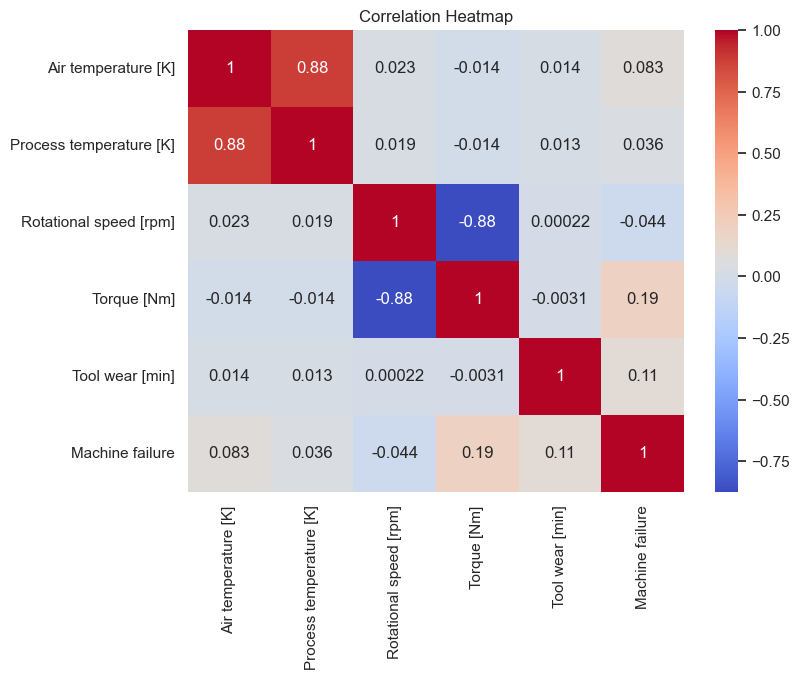

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

 Correlation values close to 1 or -1 indicate strong relationships between variables.

## Visualizations

#### Air Temperature and Process Temperature Are Highly Correlated

Correlation: 0.8761071581166635


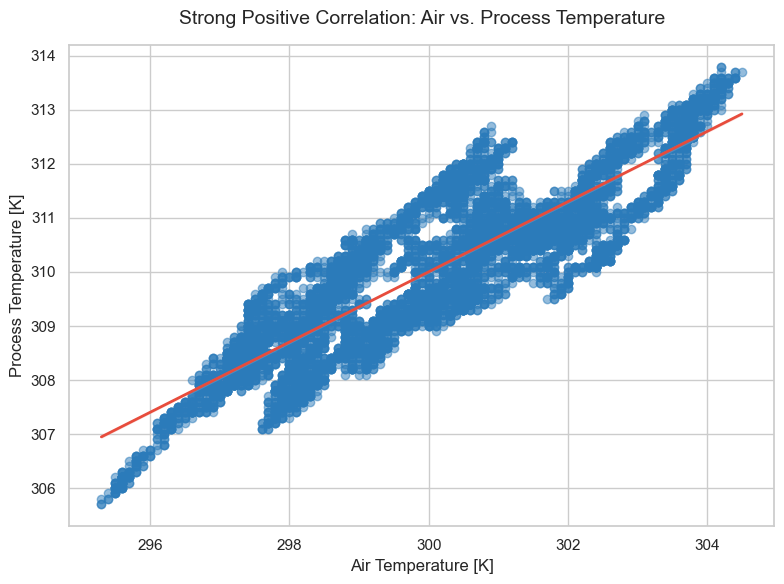

In [109]:
temp_corr = df['Air temperature [K]'].corr(df['Process temperature [K]'])

print("Correlation:", temp_corr)

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create the scatter plot with a regression trendline
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='Air temperature [K]',
    y='Process temperature [K]',
    scatter_kws={'alpha':0.5, 'color': '#2b7bba'}, # Makes dense points semi-transparent
    line_kws={'color': '#e74c3c', 'linewidth': 2}    # Highlights the positive trend line
)

# Add clear titles and labels
plt.title('Strong Positive Correlation: Air vs. Process Temperature', fontsize=14, pad=15)
plt.xlabel('Air Temperature [K]', fontsize=12)
plt.ylabel('Process Temperature [K]', fontsize=12)

plt.tight_layout()
plt.show()

Correlation close to +1 → strong positive relationship.
This supports the claim that environmental temperature influences process temperature.

#### Distribution of Rotational Speed / Speed and Torque Relationship

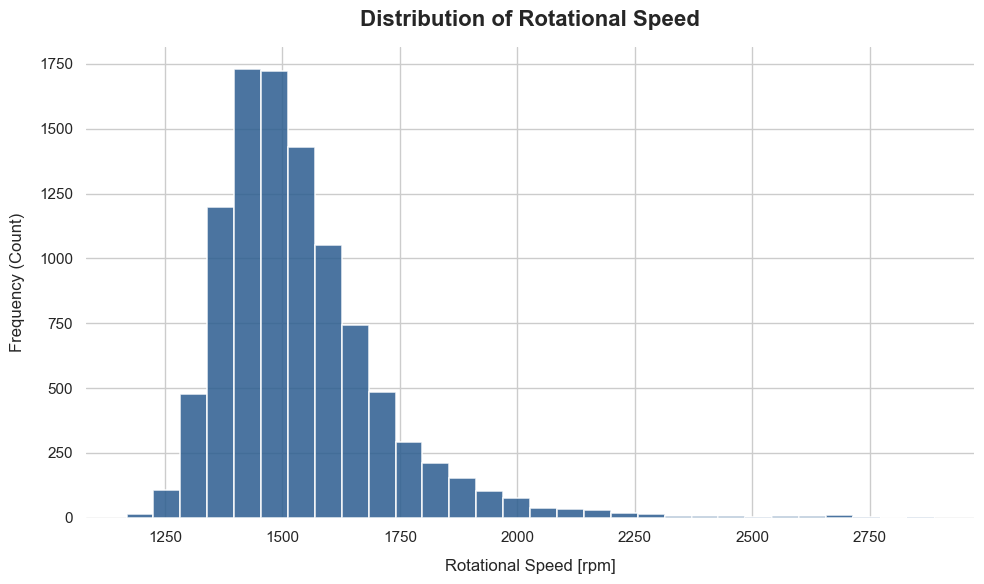

In [110]:
# Rotational Speed Distribution
# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))  # Slightly larger for better readability

# Plot histogram with clean colors, distinct edges, and a density curve option
plt.hist(
    df['Rotational speed [rpm]'], 
    bins=30, 
    color='#2b5c8f',       # Professional deep blue
    edgecolor='#ffffff',    # White edges to distinctly separate the bars
    linewidth=1.2,
    alpha=0.85
)

# Format titles and labels with clear hierarchy and font weights
plt.title('Distribution of Rotational Speed', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rotational Speed [rpm]', fontsize=12, labelpad=10)
plt.ylabel('Frequency (Count)', fontsize=12, labelpad=10)

# Clean up layout and remove the top and right borders (spines)
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

This histogram shows how rotational speed values are distributed across the dataset.

In [111]:
# Rotational Speed Has the Highest Variability
stds = df[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]].std()

print(stds.sort_values(ascending=False))

variances = df[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]].var()

print(variances.sort_values(ascending=False))

Rotational speed [rpm]     179.284096
Tool wear [min]             63.654147
Torque [Nm]                  9.968934
Air temperature [K]          2.000259
Process temperature [K]      1.483734
dtype: float64
Rotational speed [rpm]     32142.787047
Tool wear [min]             4051.850384
Torque [Nm]                   99.379640
Air temperature [K]            4.001035
Process temperature [K]        2.201467
dtype: float64


The largest standard deviation/variance identifies the most variable feature.

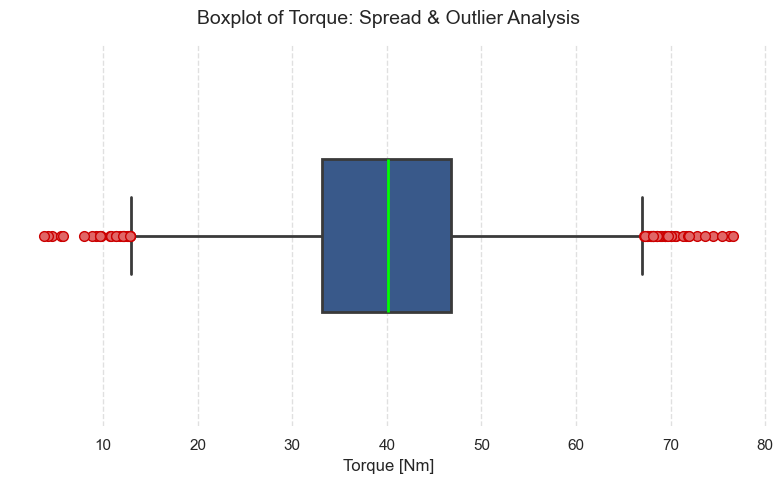

In [112]:
# Set a clean presentation style
sns.set_theme(style="whitegrid")

# Initialize your original figure size
plt.figure(figsize=(8, 5))

# Create the improved boxplot using your exact column name
sns.boxplot(
    x=df["Torque [Nm]"],
    color="#2b5797",  # Professional corporate blue
    width=0.4,
    linewidth=2,
    flierprops={
        "marker": "o",
        "markerfacecolor": "#e06666",  # Distinct light red outliers
        "markeredgecolor": "#cc0000",
        "markersize": 7,
    },
    medianprops={
        "color": "#00ff00",
        "linewidth": 2,
    },  # Clean green line to show concentration
)

# Apply your original labels with polished formatting
plt.title("Boxplot of Torque: Spread & Outlier Analysis", fontsize=14, pad=15)
plt.xlabel("Torque [Nm]", fontsize=12)

# Clean up chart borders to look great on presentation slides
plt.gca().xaxis.grid(True, linestyle="--", alpha=0.6)
plt.gca().yaxis.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

The boxplot helps identify outliers and shows the spread of torque values.

Correlation: -0.8750270862996065


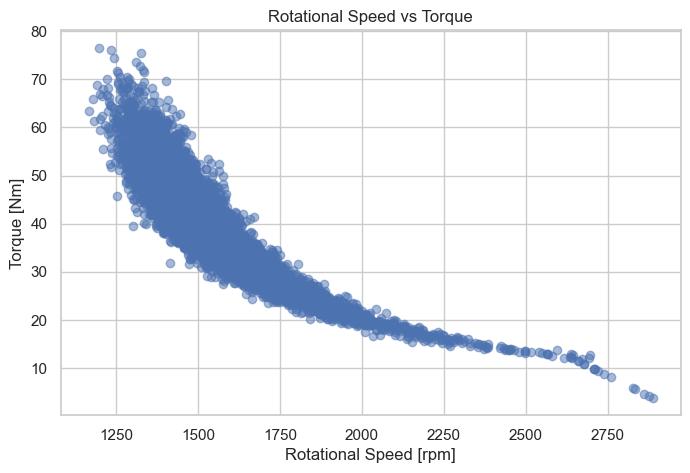

In [113]:
# Rotational Speed and Torque Have a Negative Relationship
speed_torque_corr = df['Rotational speed [rpm]'].corr(df['Torque [Nm]'])

print("Correlation:", speed_torque_corr)

plt.figure(figsize=(8,5))
plt.scatter(df['Rotational speed [rpm]'],
            df['Torque [Nm]'],
            alpha=0.5)

plt.title('Rotational Speed vs Torque')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

This scatter plot shows the relationship between rotational speed and torque. Negative correlation confirms the inverse relationship.

#### Tool Wear Is Associated With Machine Failure

Correlation: 0.1054482189195954


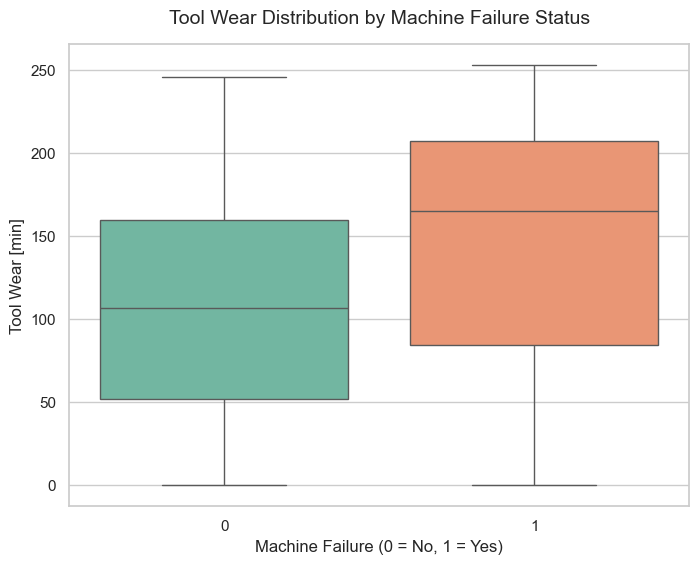

In [114]:
toolwear_failure_corr = df['Tool wear [min]'].corr(df['Machine failure'])

print("Correlation:", toolwear_failure_corr)

df.groupby('Machine failure')['Tool wear [min]'].mean()

# Set the style
sns.set_theme(style="whitegrid")

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df, 
    x='Machine failure', 
    y='Tool wear [min]', 
    hue='Machine failure',  # Maps colors to the groups
    legend=False,           # Removes the redundant legend
    palette='Set2'
)

# Add clear labels and title
plt.title('Tool Wear Distribution by Machine Failure Status', fontsize=14, pad=15)
plt.xlabel('Machine Failure (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Tool Wear [min]', fontsize=12)

plt.show()

Failed machines should have higher average tool wear.

#### Machine Failures are rare

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


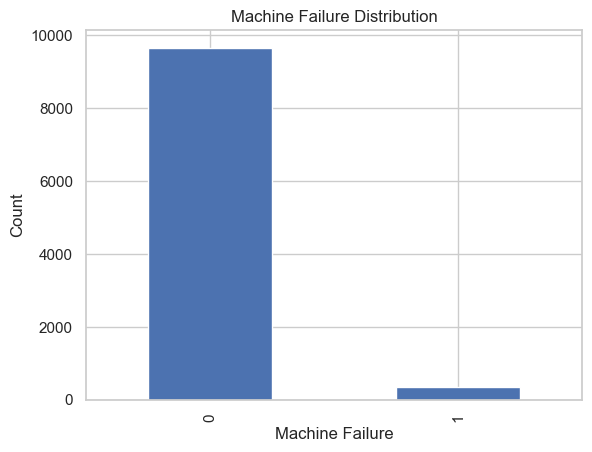

In [115]:
failure_counts = df['Machine failure'].value_counts()

print(failure_counts)

print("\nPercentage:")
print(df['Machine failure'].value_counts(normalize=True) * 100)

df['Machine failure'].value_counts().plot(
    kind='bar',
    title='Machine Failure Distribution'
)

plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.show()

Shows class imbalance (0 = No Failure, 1 = Failure)

#### Machine Failure by Product Type 


Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64


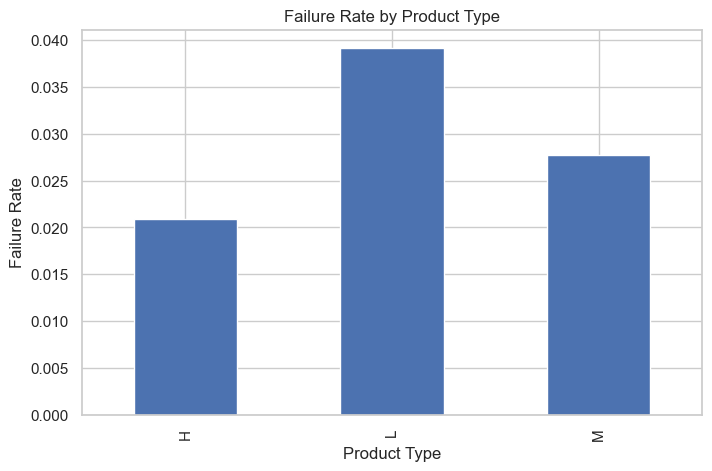

In [116]:
# Product Types Have Different Failure Rates
failure_by_type = df.groupby('Type')['Machine failure'].mean()
print(failure_by_type)

plt.figure(figsize=(8,5))
failure_by_type.plot(kind='bar')
plt.title('Failure Rate by Product Type')

plt.xlabel('Product Type')
plt.ylabel('Failure Rate')
plt.show()

This bar chart compares machine failure rates between different product types. The tallest bar indicates the product type with the highest failure rate.

#### Tool Wear Has a Wide Range

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64


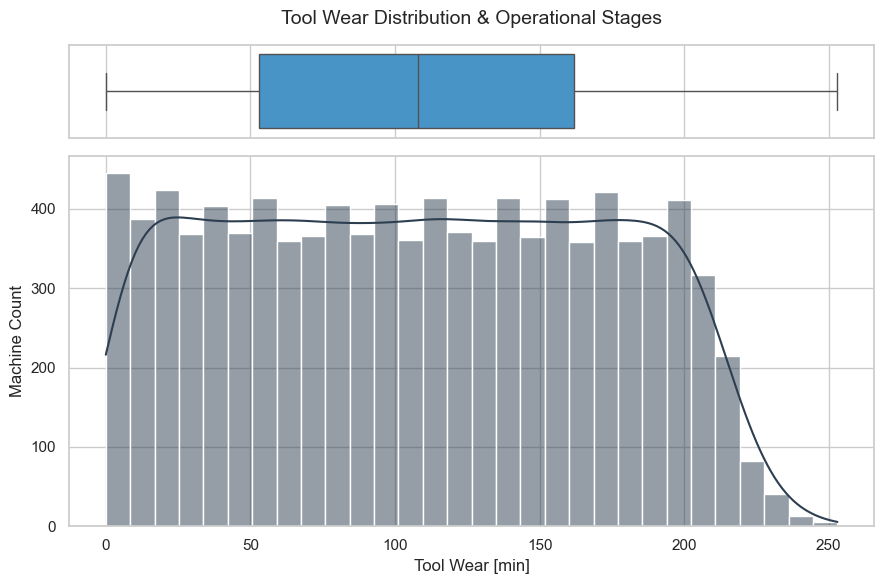

In [117]:
# Tool Wear Has a Wide Range
print(df['Tool wear [min]'].describe())

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create a figure with two subplots sharing the same x-axis
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(9, 6), 
    sharex=True, 
    gridspec_kw={"height_ratios": (.2, .8)} # Makes the boxplot smaller on top
)

# 1. Top Plot: Boxplot to show spread, median, and quartiles
sns.boxplot(
    data=df, 
    x='Tool wear [min]', 
    ax=ax_box, 
    color='#3498db',
    fliersize=4
)
ax_box.set(xlabel='') # Clear xlabel for the top plot
ax_box.set_title('Tool Wear Distribution & Operational Stages', fontsize=14, pad=15)

# 2. Bottom Plot: Histogram + Density Curve to show frequency of wear stages
sns.histplot(
    data=df, 
    x='Tool wear [min]', 
    ax=ax_hist, 
    kde=True,          # Adds the smooth kernel density estimate line
    color='#2c3e50', 
    bins=30            # Adjust bins based on dataset size
)
ax_hist.set_xlabel('Tool Wear [min]', fontsize=12)
ax_hist.set_ylabel('Machine Count', fontsize=12)

# Clean up layout margins
plt.tight_layout()
plt.show()

Large range and spread indicate machines are at different stages of wear.

#### Failure Types Explain Machine Failure

In [118]:
# Failure Types Explain Machine Failure
failure_columns = [
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF',
    'Machine failure'
]
print(df[failure_columns].corr())

# Check how failures are composed
print(df[['TWF','HDF','PWF','OSF','RNF']].sum())

                      TWF       HDF       PWF       OSF       RNF  \
TWF              1.000000 -0.007332  0.008577  0.038243  0.030970   
HDF             -0.007332  1.000000  0.018443  0.046396 -0.004706   
PWF              0.008577  0.018443  1.000000  0.115836 -0.004273   
OSF              0.038243  0.046396  0.115836  1.000000 -0.004341   
RNF              0.030970 -0.004706 -0.004273 -0.004341  1.000000   
Machine failure  0.362904  0.575800  0.522812  0.531083  0.004516   

                 Machine failure  
TWF                     0.362904  
HDF                     0.575800  
PWF                     0.522812  
OSF                     0.531083  
RNF                     0.004516  
Machine failure         1.000000  
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


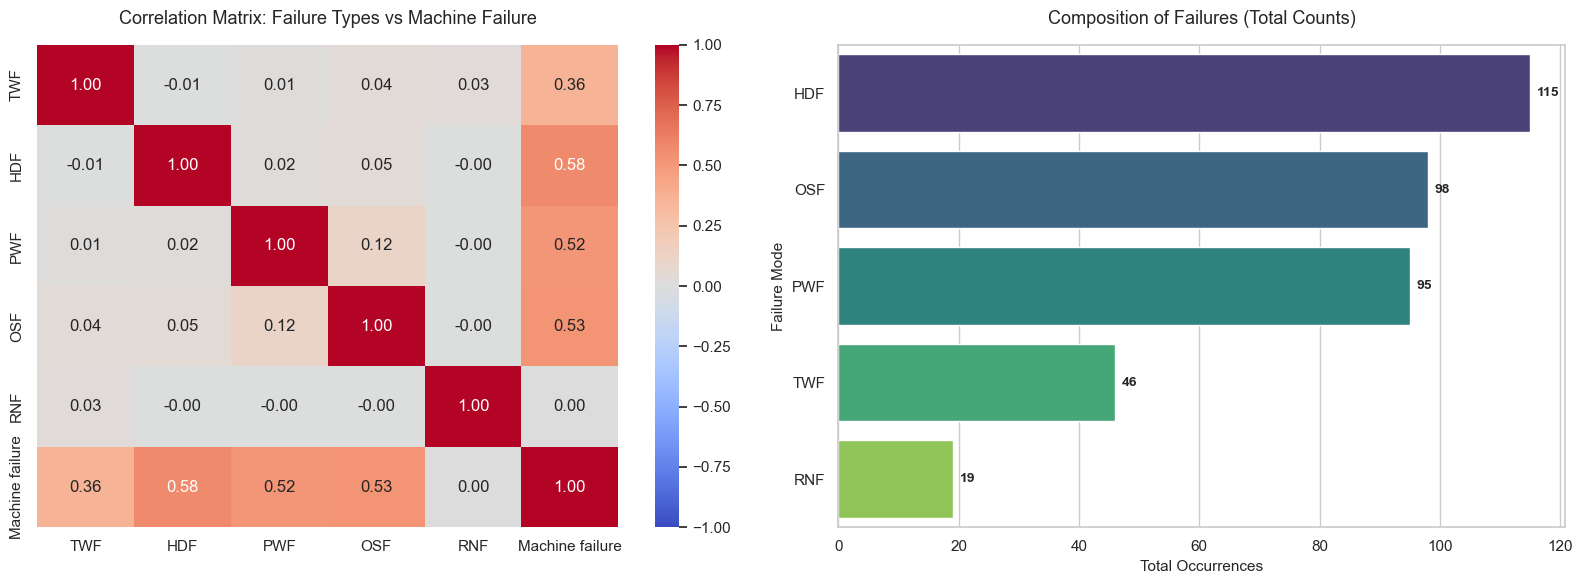

In [119]:
# Define the columns
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_columns = failure_types + ['Machine failure']

# Setup a 1-row, 2-column figure layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# 1. Left Plot: Correlation Heatmap
corr_matrix = df[failure_columns].corr()
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the numerical correlation values
    cmap='coolwarm',     # Red for positive correlation, blue for negative
    fmt=".2f", 
    vmin=-1, vmax=1,     # Anchors the scale from -1 to +1
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix: Failure Types vs Machine Failure', fontsize=13, pad=15)

# 2. Right Plot: Total Breakdown (Composition)
failure_sums = df[failure_types].sum().sort_values(ascending=False)
sns.barplot(
    x=failure_sums.values, 
    y=failure_sums.index, 
    hue=failure_sums.index, # Prevents future deprecation warnings
    legend=False,
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('Composition of Failures (Total Counts)', fontsize=13, pad=15)
axes[1].set_xlabel('Total Occurrences', fontsize=11)
axes[1].set_ylabel('Failure Mode', fontsize=11)

# Display value labels on the bars for quick reading
for i, val in enumerate(failure_sums.values):
    axes[1].text(val + (max(failure_sums.values) * 0.01), i, f'{int(val)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

- Strong correlations show these variables are directly connected to machine failures.
- Heatmap (Left): Instantly isolates which specific failure modes (like HDF or OSF) share the strongest mathematical bond with the target Machine failure flag.
- Horizontal Bar Plot (Right): Shows you exactly which failure modes are rare versus which ones happen most frequently in the dataset.

#### Shows summary of Mean, Median, STDev, & Variance

In [120]:
summary = pd.DataFrame({
    'Mean': df[[
        'Air temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]'
    ]].mean(),

    'Median': df[[
        'Air temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]'
    ]].median(),

    'Std Dev': df[[
        'Air temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]'
    ]].std(),

    'Variance': df[[
        'Air temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]'
    ]].var()
})

# Format the summary table with custom decimal rounding and a soft color gradient
styled_summary = summary.style.background_gradient(
    cmap='Blues', 
    axis=0  # Columns are colored independently based on magnitude
).format("{:,.2f}")  # Rounds numbers cleanly to 2 decimal places

# Display the styled dataframe
styled_summary

,Mean,Median,Std Dev,Variance
Air temperature [K],300.00,300.10,2.00,4.00
Rotational speed [rpm],"1,538.78","1,503.00",179.28,"32,142.79"
Torque [Nm],39.99,40.10,9.97,99.38


## Interpretation of Results

#### Distribution Insights
- Rotational Speed appears approximately normally distributed.
- Torque values contain some outliers (shown in the boxplot).
- Air and process temperatures have relatively small variation.
- Tool wear exhibits a wide range of values, indicating machines are observed at different stages of their lifecycle.
- Most observations correspond to machines operating under normal conditions, with failures occurring relatively infrequently.

#### Highest Variability
- Rotational speed has the highest variability because its values are spread over a larger numerical range.
- Temperature variables show lower variability because they remain within a narrower range.
- The high variability in rotational speed suggests that machines operate under a wide variety of workloads and operating conditions.

#### Strongest Correlations
- Air temperature and process temperature are strongly positively correlated.
- Rotational speed and torque may show a moderate negative relationship.
- The strong temperature correlation suggests that environmental conditions directly influence machine operating temperatures.
- The inverse relationship between rotational speed and torque reflects a common engineering tradeoff between speed and force.

#### Group Differences
- Some product types may experience slightly higher machine failure rates.
- Tool wear tends to increase the likelihood of machine failure.
- Differences in failure rates across product types suggest that product quality or design characteristics may influence reliability.
- Machines with greater tool wear generally exhibit a higher risk of failure compared to those with less wear.

#### Surprising Insights
- Even small changes in operational variables can influence machine failures.
- Certain failures occur despite moderate operating conditions, suggesting random failure behavior.
- Machine failures are relatively rare compared to normal operating conditions, highlighting the challenge of identifying failures in advance.
- Multiple failure mechanisms exist (tool wear, heat dissipation, power, overstrain, and random failures), showing that machine failures can arise from several distinct causes.

## Conclusion

The analysis of the AI4I 2020 Predictive Maintenance dataset revealed several important patterns in machine operation and failure behavior. Data wrangling showed that the dataset was clean and suitable for analysis. Descriptive statistics indicated that rotational speed exhibited the greatest variability, while temperature measurements remained relatively stable. Correlation analysis revealed a strong positive relationship between air temperature and process temperature, as well as a negative relationship between rotational speed and torque. Additionally, increased tool wear was associated with a greater likelihood of machine failure, highlighting the importance of preventative maintenance. The visualizations further demonstrated differences in machine behavior and failure rates across product types. Overall, the results suggest that operational conditions, component wear, and machine characteristics all contribute to machine reliability, demonstrating how data analysis can be used to identify factors associated with equipment failure and support predictive maintenance strategies.